# Customer Churn Analysis and Prediction

**Objective:** Understand which bank customers are leaving (churning), why they are leaving, and build a model that flags customers at high risk of churn so the bank can act before they leave.

**Dataset:** Bank Customer Churn (`Churn_Modelling.csv`), 10,000 customers with 14 columns. The target column `Exited` is 1 if the customer left the bank and 0 if they stayed.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, TensorFlow (Keras)

**Notebook outline**
1. Data loading and quality checks
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Key insights and business recommendations
5. Predictive modeling (Logistic Regression baseline and ANN)
6. Model evaluation
7. Customer risk scoring and export for the Tableau dashboard

## 1. Data Loading and Quality Checks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 10,000   Columns: 14


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Duplicate customer IDs: {df["CustomerId"].duplicated().sum()}')

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0
Duplicate customer IDs: 0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.00,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.00,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.00,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.00,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.00,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.00,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.00,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.00,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.00,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.00,100090.24,57510.49,11.58,51002.11,100193.91,149388.25,199992.48


**Observation:** The data is clean. There are no missing values and no duplicate rows or customer IDs, so no imputation is needed.

## 2. Data Cleaning

`RowNumber`, `CustomerId` and `Surname` are identifiers. They carry no information about churn behavior, so they are removed. A separate copy `eda` is used for analysis so that helper columns added for EDA do not leak into the model.

In [6]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

eda = df.copy()
eda['Churned'] = eda['Exited'].map({0: 'Stayed', 1: 'Churned'})
eda['AgeGroup'] = pd.cut(eda['Age'], bins=[17, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])
eda['BalanceGroup'] = np.where(eda['Balance'] == 0, 'Zero balance', 'Has balance')
eda['ActiveStatus'] = eda['IsActiveMember'].map({0: 'Inactive', 1: 'Active'})
eda.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churned,AgeGroup,BalanceGroup,ActiveStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Churned,41-50,Zero balance,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Stayed,41-50,Has balance,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Churned,41-50,Has balance,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Stayed,31-40,Zero balance,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Stayed,41-50,Has balance,Active


## 3. Exploratory Data Analysis

### 3.1 Overall churn rate

Overall churn rate: 20.4%
Churned
Stayed     7963
Churned    2037
Name: count, dtype: int64


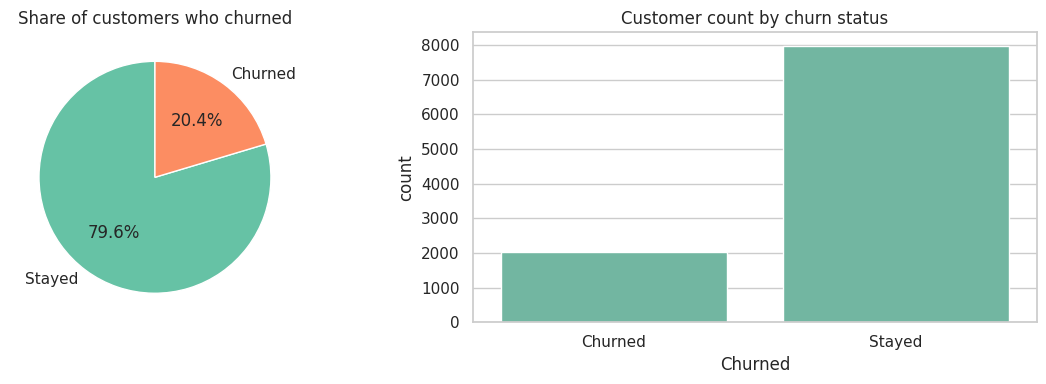

In [7]:
churn_rate = eda['Exited'].mean()
print(f'Overall churn rate: {churn_rate:.1%}')
print(eda['Churned'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda['Churned'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], startangle=90,
                                       colors=['#66c2a5', '#fc8d62'])
axes[0].set_ylabel('')
axes[0].set_title('Share of customers who churned')
sns.countplot(data=eda, x='Churned', ax=axes[1])
axes[1].set_title('Customer count by churn status')
plt.tight_layout()
plt.show()

About 1 in 5 customers left the bank. The classes are **imbalanced** (roughly 80/20), which matters later: a model that always predicts "Stayed" would already be about 80% accurate, so accuracy alone is not a good measure.

### 3.2 Churn rate by customer segment

In [8]:
def churn_by(col):
    """Return customer count, churned count and churn rate (%) for each value of a column."""
    summary = eda.groupby(col, observed=True)['Exited'].agg(Customers='count', Churned='sum')
    summary['Churn Rate (%)'] = (summary['Churned'] / summary['Customers'] * 100).round(1)
    return summary

segments = ['Geography', 'Gender', 'ActiveStatus', 'NumOfProducts', 'AgeGroup', 'BalanceGroup']
for col in segments:
    print(f'--- {col} ---')
    print(churn_by(col), '\n')

--- Geography ---
           Customers  Churned  Churn Rate (%)
Geography                                    
France          5014      810           16.20
Germany         2509      814           32.40
Spain           2477      413           16.70 

--- Gender ---
        Customers  Churned  Churn Rate (%)
Gender                                    
Female       4543     1139           25.10
Male         5457      898           16.50 

--- ActiveStatus ---
              Customers  Churned  Churn Rate (%)
ActiveStatus                                    
Active             5151      735           14.30
Inactive           4849     1302           26.90 

--- NumOfProducts ---


               Customers  Churned  Churn Rate (%)
NumOfProducts                                    
1                   5084     1409           27.70
2                   4590      348            7.60
3                    266      220           82.70
4                     60       60          100.00 

--- AgeGroup ---
          Customers  Churned  Churn Rate (%)
AgeGroup                                    
18-30          1968      148            7.50
31-40          4451      538           12.10
41-50          2320      788           34.00
51-60           797      448           56.20
60+             464      115           24.80 

--- BalanceGroup ---
              Customers  Churned  Churn Rate (%)
BalanceGroup                                    
Has balance        6383     1537           24.10
Zero balance       3617      500           13.80 



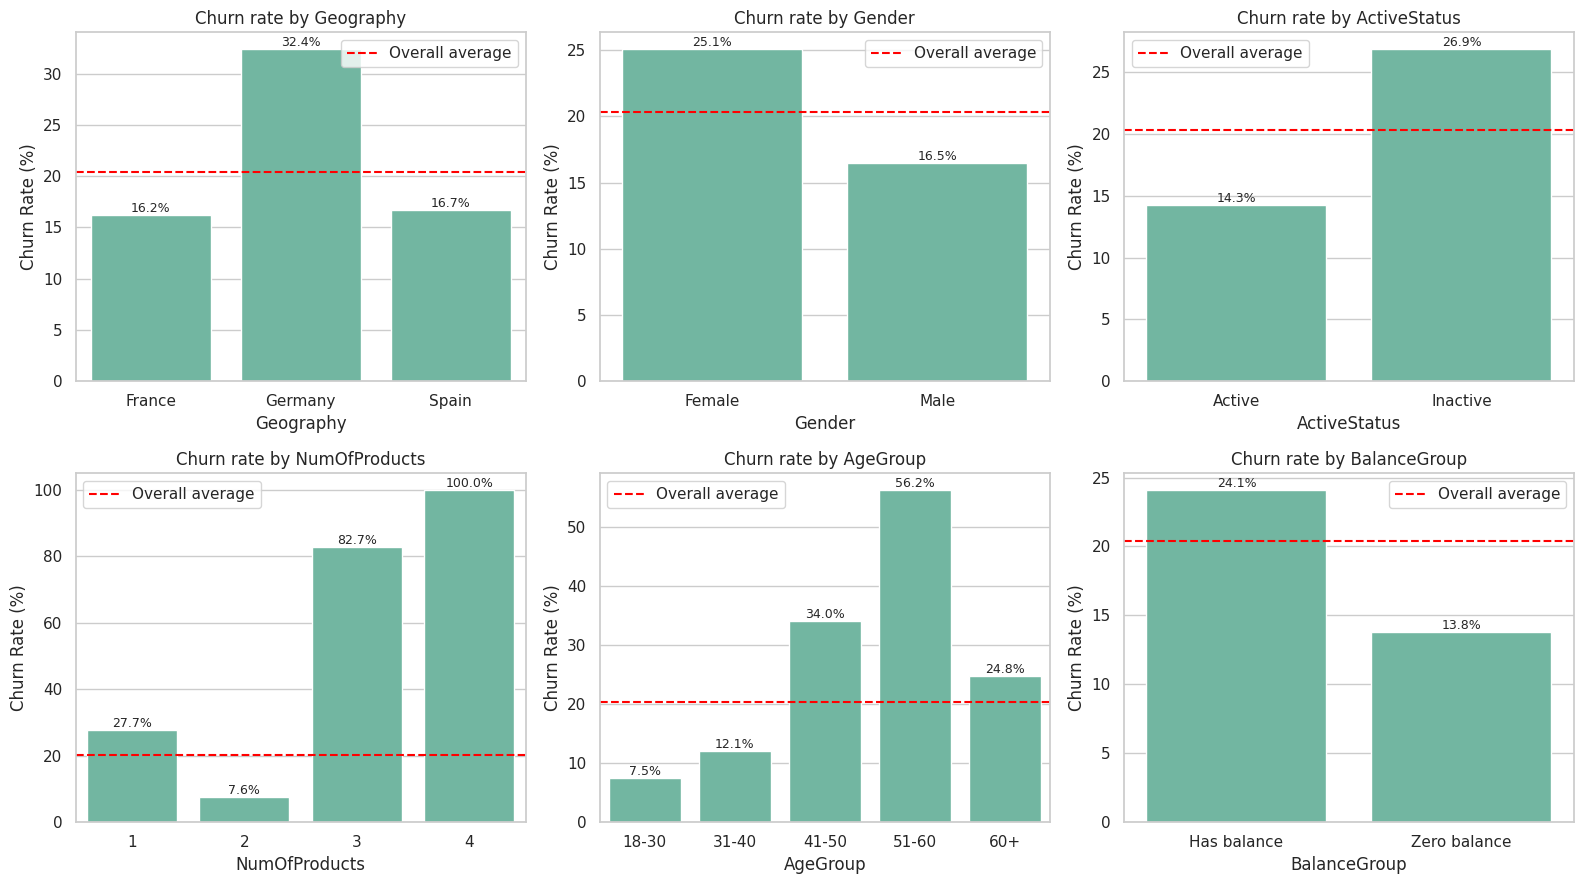

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, segments):
    data = churn_by(col).reset_index()
    sns.barplot(data=data, x=col, y='Churn Rate (%)', ax=ax)
    ax.axhline(churn_rate * 100, color='red', linestyle='--', label='Overall average')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Churn rate by {col}')
    ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Numeric features: churned vs stayed

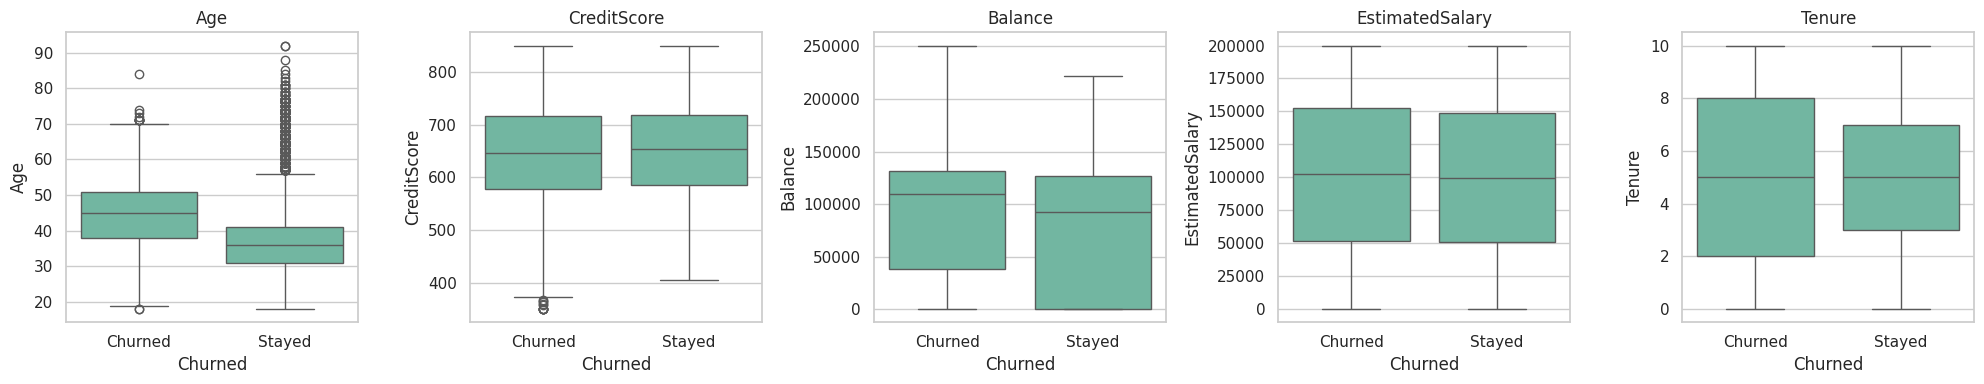

,Age,CreditScore,Balance,EstimatedSalary,Tenure
Churned,,,,,
Churned,45.00,646.00,109349.29,102460.84,5.00
Stayed,36.00,653.00,92072.68,99645.04,5.00


In [10]:
num_cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Tenure']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=eda, x='Churned', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

eda.groupby('Churned')[num_cols].median()

Age shows the clearest difference: churned customers are noticeably older. Credit score, estimated salary and tenure look very similar for both groups, so they are weak churn drivers on their own.

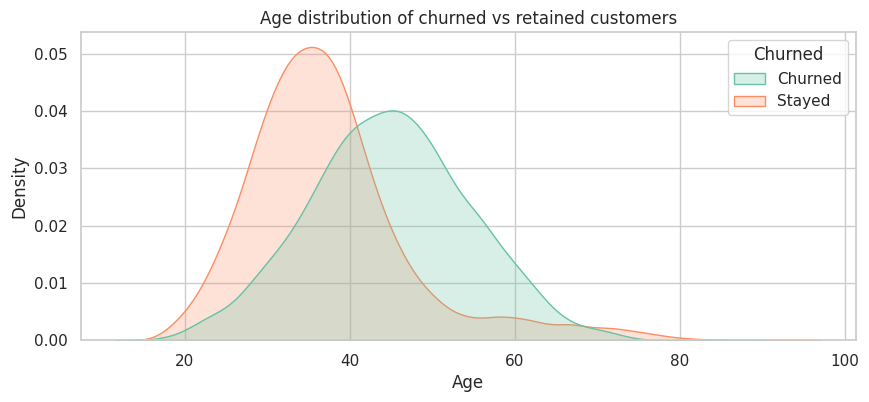

In [11]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=eda, x='Age', hue='Churned', fill=True, common_norm=False)
plt.title('Age distribution of churned vs retained customers')
plt.show()

### 3.4 Combined segments: Geography x Gender and Geography x Activity

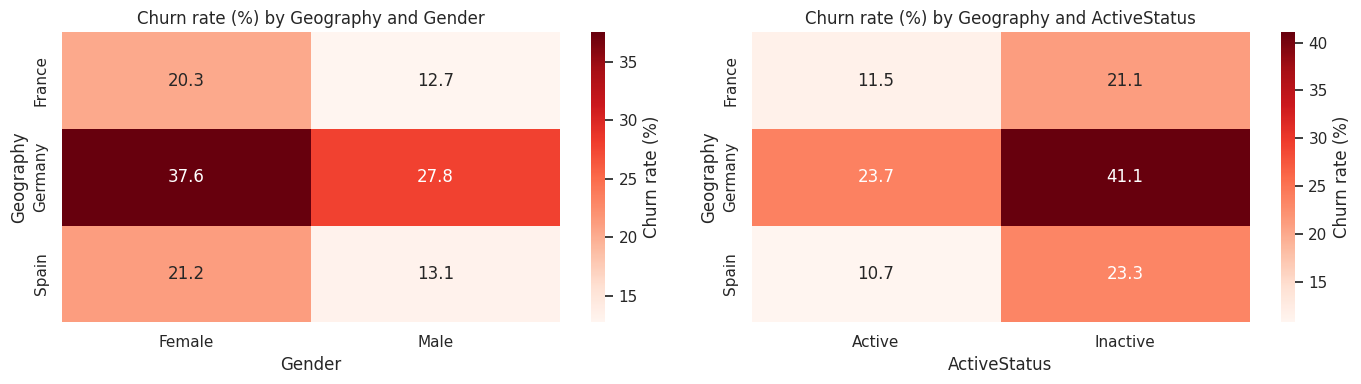

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Gender', 'ActiveStatus']):
    pivot = eda.pivot_table(index='Geography', columns=col, values='Exited', aggfunc='mean') * 100
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': 'Churn rate (%)'})
    ax.set_title(f'Churn rate (%) by Geography and {col}')
plt.tight_layout()
plt.show()

### 3.5 Revenue impact: balance at risk

In [13]:
total_balance = eda['Balance'].sum()
lost_balance = eda.loc[eda['Exited'] == 1, 'Balance'].sum()
print(f'Total customer balance:      {total_balance:,.0f}')
print(f'Balance held by churners:    {lost_balance:,.0f}')
print(f'Share of balance lost:       {lost_balance / total_balance:.1%}')

geo_balance = eda.groupby('Geography').agg(
    AvgBalance=('Balance', 'mean'),
    ChurnRate=('Exited', 'mean'),
    BalanceLost=('Balance', lambda s: s[eda.loc[s.index, 'Exited'] == 1].sum()))
geo_balance['ChurnRate'] = (geo_balance['ChurnRate'] * 100).round(1)
geo_balance

Total customer balance:      764,858,893
Balance held by churners:    185,588,095
Share of balance lost:       24.3%


,AvgBalance,ChurnRate,BalanceLost
Geography,,,
France,62092.64,16.20,57666164.54
Germany,119730.12,32.40,97973915.53
Spain,61818.15,16.70,29948014.56


### 3.6 Correlation with churn

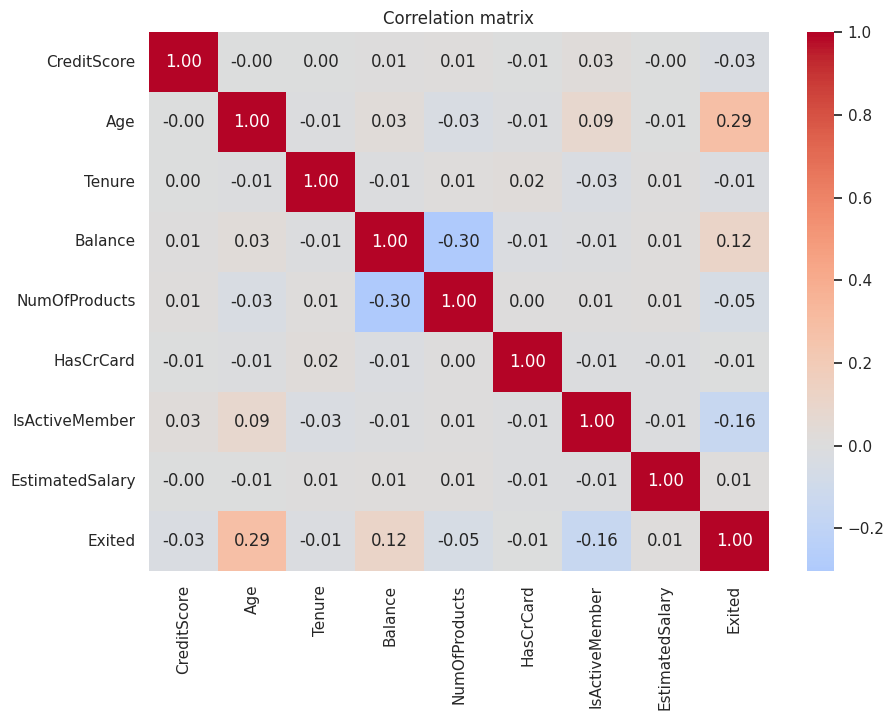

Age                0.29
IsActiveMember    -0.16
Balance            0.12
NumOfProducts     -0.05
CreditScore       -0.03
Tenure            -0.01
EstimatedSalary    0.01
HasCrCard         -0.01
Name: Exited, dtype: float64

In [14]:
corr = df.select_dtypes('number').corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False)

## 4. Key Insights and Business Recommendations

1. **About 1 in 5 customers churned (20.4%)**, and they held **about 24% of the bank's total balance**, so churn has a large revenue impact.
2. **Germany has double the churn rate** of France and Spain (about 32% vs 16 to 17%), and German customers also hold the highest average balance. *Recommendation:* investigate the German market (pricing, service quality, competitors) as the top priority.
3. **Age is the strongest driver.** Churn rises sharply from about 8% for ages 18 to 30 to about 56% for ages 51 to 60. *Recommendation:* create retention offers and dedicated relationship managers for customers aged 40 to 60.
4. **Inactive members churn almost twice as often** as active members (about 27% vs 14%). *Recommendation:* run re-engagement campaigns (app nudges, rewards) when a customer becomes inactive.
5. **Product count matters.** Customers with 2 products churn the least (about 8%), customers with 1 product churn at about 28%, and almost everyone with 3 or 4 products left. *Recommendation:* cross-sell a second product to single-product customers, and review why customers with 3+ products are leaving (possible product dissatisfaction or mis-selling).
6. **Female customers churn more** than male customers (about 25% vs 17%), which is worth exploring with customer feedback.
7. Credit score, salary, tenure and owning a credit card show **little relationship** with churn.

## 5. Predictive Modeling

The goal is to flag customers likely to churn. Because missing a churner is costly for the bank, **recall on the churn class** is the most important metric, along with ROC-AUC. Accuracy is reported but not relied on.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

X = df.drop(columns='Exited')
y = df['Exited']

# stratify keeps the same 80/20 churn ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Churn rate  train: {y_train.mean():.1%}   test: {y_test.mean():.1%}')

Train: (8000, 10)   Test: (2000, 10)
Churn rate  train: 20.4%   test: 20.3%


In [16]:
cat_cols = ['Geography', 'Gender']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)])

# fit only on training data to avoid data leakage
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['cat__Geography_Germany' 'cat__Geography_Spain' 'cat__Gender_Male'
 'num__CreditScore' 'num__Age' 'num__Tenure' 'num__Balance'
 'num__NumOfProducts' 'num__HasCrCard' 'num__IsActiveMember'
 'num__EstimatedSalary']


### 5.1 Baseline: Logistic Regression

In [17]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_p, y_train)
lr_prob = log_reg.predict_proba(X_test_p)[:, 1]
lr_pred = (lr_prob > 0.5).astype(int)
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_prob):.3f}')

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC: 0.777


### 5.2 Artificial Neural Network (ANN)

In [18]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

# give the minority (churn) class more weight so the model does not ignore it
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight = {0: round(float(weights[0]), 2), 1: round(float(weights[1]), 2)}
print('Class weights:', class_weight)

Class weights: {0: 0.63, 1: 2.45}


In [19]:
ann = Sequential([
    Input(shape=(X_train_p.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # sigmoid outputs a churn probability between 0 and 1
])
ann.compile(optimizer='adam', loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = ann.fit(X_train_p, y_train,
                  validation_split=0.2,
                  epochs=200, batch_size=32,
                  class_weight=class_weight,
                  callbacks=[early_stop],
                  verbose=0)
print(f'Training stopped after {len(history.history["loss"])} epochs')

Training stopped after 54 epochs


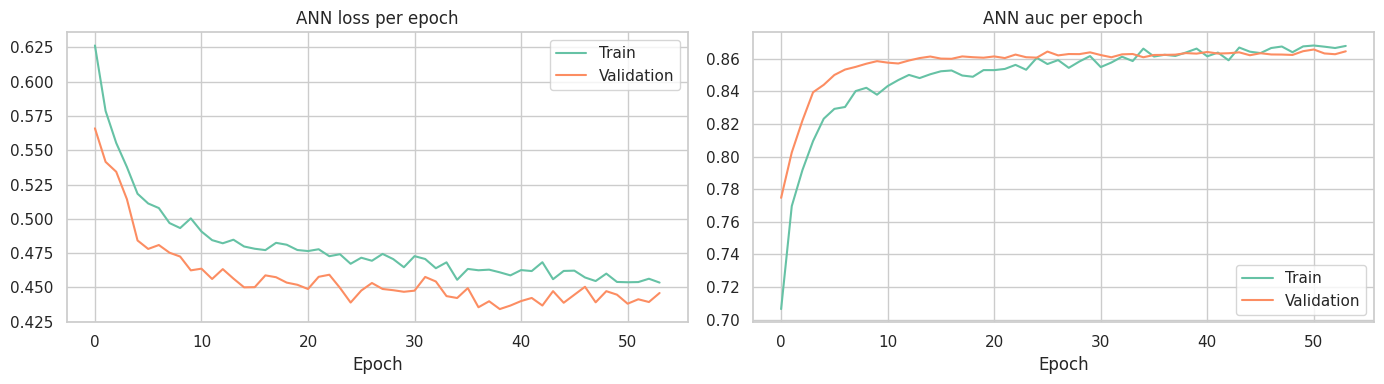

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ['loss', 'auc']):
    ax.plot(history.history[metric], label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Validation')
    ax.set_title(f'ANN {metric} per epoch')
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Model Evaluation

In [22]:
ann_prob = ann.predict(X_test_p, verbose=0).ravel()
ann_pred = (ann_prob > 0.5).astype(int)
print(classification_report(y_test, ann_pred, target_names=['Stayed', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, ann_prob):.3f}')

              precision    recall  f1-score   support

      Stayed       0.92      0.81      0.86      1593
     Churned       0.50      0.74      0.60       407

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.84      0.80      0.81      2000

ROC-AUC: 0.860


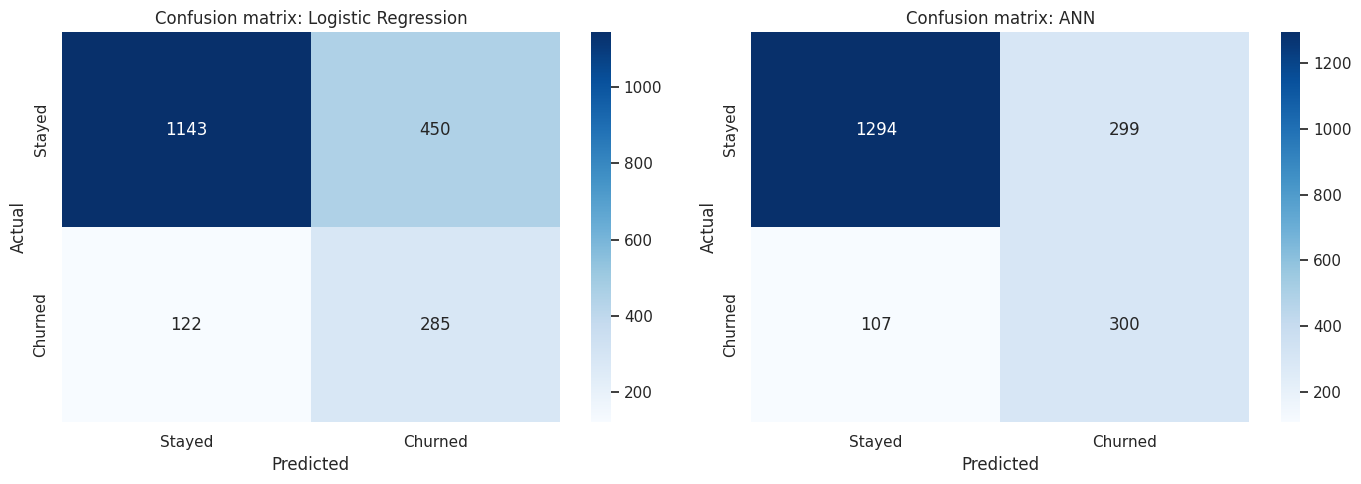

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes, [('Logistic Regression', lr_pred), ('ANN', ann_pred)]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    ax.set_title(f'Confusion matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

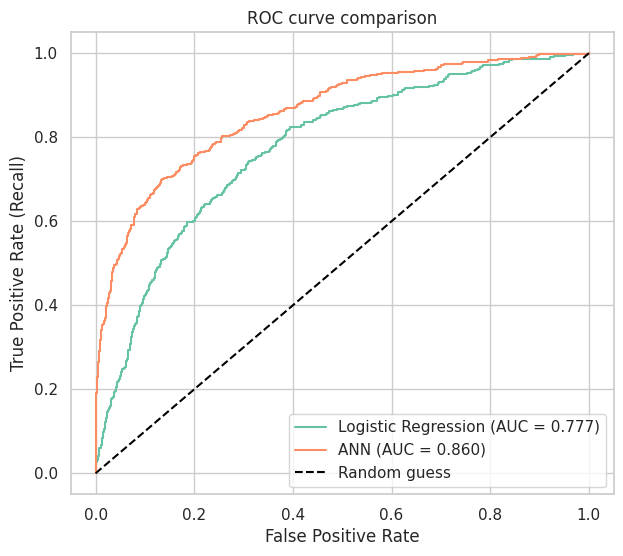

In [24]:
plt.figure(figsize=(7, 6))
for name, prob in [('Logistic Regression', lr_prob), ('ANN', ann_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC curve comparison')
plt.legend()
plt.show()

In [25]:
results = pd.DataFrame({
    name: {'Accuracy': accuracy_score(y_test, pred),
           'Precision': precision_score(y_test, pred),
           'Recall': recall_score(y_test, pred),
           'F1 Score': f1_score(y_test, pred),
           'ROC-AUC': roc_auc_score(y_test, prob)}
    for name, pred, prob in [('Logistic Regression', lr_pred, lr_prob), ('ANN', ann_pred, ann_prob)]
}).T.round(3)
results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.71,0.39,0.70,0.50,0.78
ANN,0.80,0.50,0.74,0.60,0.86


**Interpretation:** Using class weights trades a little accuracy for much higher recall, meaning the model now catches far more of the customers who actually leave. The ANN outperforms the Logistic Regression baseline on ROC-AUC, which shows it captures non-linear patterns (such as the age and product-count effects seen in the EDA).

## 7. Customer Risk Scoring and Export for Tableau

The trained ANN scores every customer with a churn probability. Customers are then grouped into risk segments that the retention team can act on. The exported file is the data source for the Tableau dashboard.

In [26]:
dashboard = eda.drop(columns=['Churned']).copy()
dashboard['ChurnProbability'] = ann.predict(preprocessor.transform(X), verbose=0).ravel().round(3)
dashboard['RiskSegment'] = pd.cut(dashboard['ChurnProbability'], bins=[0, 0.4, 0.7, 1.0],
                                  labels=['Low', 'Medium', 'High'], include_lowest=True)

risk_summary = dashboard.groupby('RiskSegment', observed=True).agg(
    Customers=('Exited', 'count'),
    ActualChurnRate=('Exited', 'mean'),
    TotalBalance=('Balance', 'sum'))
risk_summary['ActualChurnRate'] = (risk_summary['ActualChurnRate'] * 100).round(1)
risk_summary

,Customers,ActualChurnRate,TotalBalance
RiskSegment,,,
Low,5846,5.20,367397216.70
Medium,2556,24.00,253887317.70
High,1598,70.20,143574358.48


In [27]:
dashboard.to_csv('churn_dashboard_data.csv', index=False)
print(f'Saved churn_dashboard_data.csv with {dashboard.shape[0]:,} rows and {dashboard.shape[1]} columns')

Saved churn_dashboard_data.csv with 10,000 rows and 16 columns


## 8. Conclusion

* About **20% of customers churned**, taking roughly **a quarter of the bank's total balance** with them.
* The biggest churn drivers are **age (40 to 60), being in Germany, being an inactive member, and holding only 1 product (or 3+ products)**.
* A class-weighted **ANN** flags churners with much better recall than an unweighted model, and outperforms the Logistic Regression baseline on ROC-AUC.
* The **risk segments** let the bank focus retention budgets on the High risk group first, where actual churn is far above average.

**Next steps:** tune the decision threshold to match the bank's retention budget, try tree-based models (Random Forest, XGBoost) and SHAP values for explainability, and build the Tableau dashboard from `churn_dashboard_data.csv`.